In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def f(x):
 return x**2
def grad(x):
 return 2*x
x = 8
learning_rate = 0.01
iterations = 500
history = []
for i in range(iterations):
 x = x - learning_rate * grad(x)
 history.append(x)
print("Final value:", x)

Final value: 0.00032819188116378053


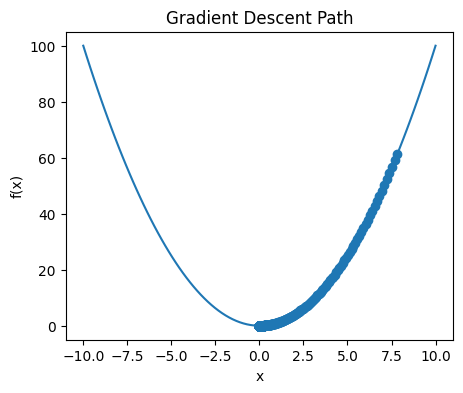

In [ ]:
x_vals = np.linspace(-10, 10, 100)
y_vals = f(x_vals)
plt.figure(figsize=(5,4))
plt.plot(x_vals, y_vals)
plt.scatter(history, [f(h) for h in history])
plt.title("Gradient Descent Path")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

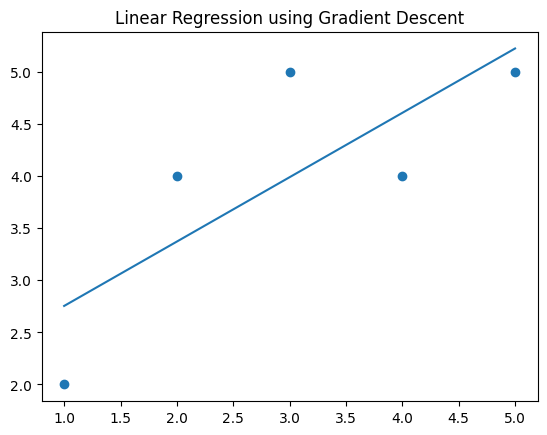

In [ ]:
plt.scatter(X, Y)
plt.plot(X, m*X + c)
plt.title("Linear Regression using Gradient Descent")
plt.show()


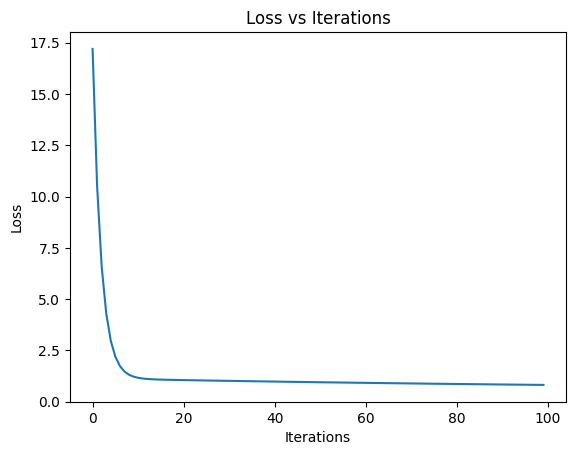

In [ ]:
losses = []
m, c = 0, 0
for i in range(100):
 y_pred = m*X + c
 loss = np.mean((Y - y_pred)**2)
 losses.append(loss)
 dm = (-2/n) * np.sum(X * (Y - y_pred))
 dc = (-2/n) * np.sum(Y - y_pred)
 m -= lr * dm
 c -= lr * dc
plt.plot(losses)
plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [ ]:
import pandas as pd
df = pd.read_csv('housing.csv')

print(df.head())
print(df.info())

   0.00632  18.00  2.310  0  0.5380  6.5750  65.20  4.0900  1  296.0  15.30  \
0  0.02731    0.0   7.07  0   0.469   6.421   78.9  4.9671  2  242.0   17.8   
1  0.02729    0.0   7.07  0   0.469   7.185   61.1  4.9671  2  242.0   17.8   
2  0.03237    0.0   2.18  0   0.458   6.998   45.8  6.0622  3  222.0   18.7   
3  0.06905    0.0   2.18  0   0.458   7.147   54.2  6.0622  3  222.0   18.7   
4  0.02985    0.0   2.18  0   0.458   6.430   58.7  6.0622  3  222.0   18.7   

   396.90  4.98  24.00  
0  396.90  9.14   21.6  
1  392.83  4.03   34.7  
2  394.63  2.94   33.4  
3  396.90  5.33   36.2  
4  394.12  5.21   28.7  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   0.00632  505 non-null    float64
 1   18.00    505 non-null    float64
 2   2.310    505 non-null    float64
 3   0        505 non-null    int64  
 4   0.5380   505 non-null    float64
 5  

In [ ]:
import numpy as np
df = df.dropna()
df = df.select_dtypes(include=[np.number])

In [ ]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.reshape(-1, 1)

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std


m = X_norm.shape[0]
X_b = np.c_[np.ones((m, 1)), X_norm]

In [ ]:
def gradient_descent(X, y, alpha=0.01, iterations=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    cost_history = []

    for i in range(iterations):
        gradients = (2/m) * X.T.dot(X.dot(theta) - y)
        theta -= alpha * gradients

        # Compute cost
        cost = (1/m) * np.sum((X.dot(theta) - y) ** 2)
        cost_history.append(cost)

    return theta, cost_history

In [ ]:
alpha = 0.01
iterations = 1000

theta, cost_history = gradient_descent(X_b, y, alpha, iterations)

In [ ]:
from sklearn.metrics import mean_squared_error
y_pred_gd = X_b.dot(theta)
mse_gd = mean_squared_error(y, y_pred_gd)

print("Gradient Descent MSE:", mse_gd)

Gradient Descent MSE: 21.92244679720428


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

y_pred_sklearn = model.predict(X)
mse_sklearn = mean_squared_error(y, y_pred_sklearn)

print("Sklearn Linear Regression MSE:", mse_sklearn)

Sklearn Linear Regression MSE: 21.865579933351402


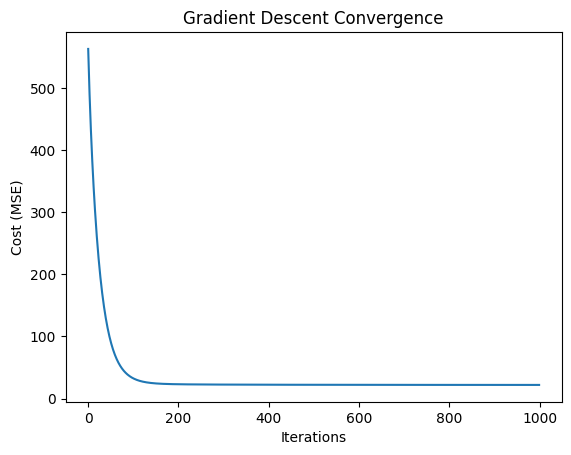

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(iterations), cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Gradient Descent Convergence')
plt.show()

In [ ]:
df = pd.read_csv('breast-cancer.csv')

print(df.head())
print(df.info())

     age mefalsepause tumor-size inv-falsedes falsede-caps  deg-malig breast  \
0  40-49   premefalse      15-19          0-2         True          3  right   
1  50-59         ge40      15-19          0-2        False          1  right   
2  50-59         ge40      35-39          0-2        False          2   left   
3  40-49   premefalse      35-39          0-2         True          3  right   
4  40-49   premefalse      30-34          3-5         True          2   left   

  breast-quad  irradiat                    class  
0     left_up     False        recurrence-events  
1     central     False  false-recurrence-events  
2    left_low     False        recurrence-events  
3    left_low      True  false-recurrence-events  
4    right_up     False        recurrence-events  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           272 n

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target.reshape(-1, 1)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [ ]:
m_train = X_train.shape[0]
m_test = X_test.shape[0]

X_train = np.c_[np.ones((m_train, 1)), X_train]
X_test = np.c_[np.ones((m_test, 1)), X_test]

In [ ]:
 def sigmoid(z):
    return 1 / (1 + np.exp(-z))



def compute_cost(X, y, theta):
    m = len(y)
    h = sigmoid(X @ theta)
    epsilon = 1e-8
    cost = -(1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return cost

In [ ]:

alpha = 0.01
iterations = 2000

theta, cost_history = gradient_descent(X_train, y_train, alpha, iterations)

print("Final cost:", cost_history[-1])

Final cost: 0.053749444223240656


In [ ]:
def predict(X, theta, threshold=0.5):
    probs = sigmoid(X @ theta)
    return (probs >= threshold).astype(int)

# Predictions on test set

y_pred = predict(X_test, theta)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7543859649122807

Confusion Matrix:
[[15 28]
 [ 0 71]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.35      0.52        43
           1       0.72      1.00      0.84        71

    accuracy                           0.75       114
   macro avg       0.86      0.67      0.68       114
weighted avg       0.82      0.75      0.72       114



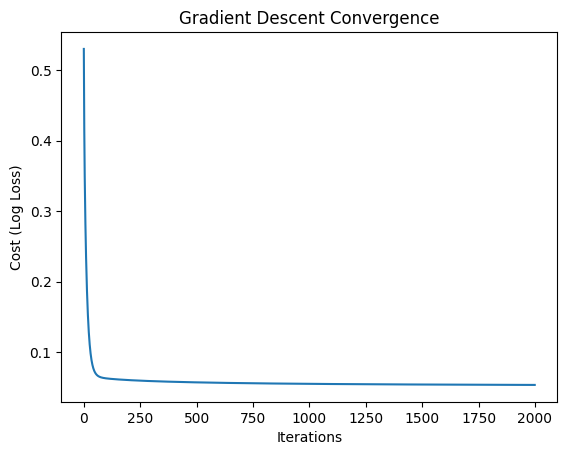

In [ ]:
plt.figure()
plt.plot(range(iterations), cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost (Log Loss)")
plt.title("Gradient Descent Convergence")
plt.show()
